In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from textblob import TextBlob
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from scipy.sparse import hstack

from sklearn.pipeline import Pipeline


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
##Connect to google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
#Change the current working directory
os.chdir('/content/gdrive/My Drive/ACM')

# Print the current working directory
print("Current working directory: {0}".format(os.getcwd()))

Current working directory: /content/gdrive/My Drive/ACM


In [4]:
df = pd.read_json("problems_data.jsonl", lines=True)
df.head()


,title,description,input_description,output_description,sample_io,problem_class,problem_score,url
0,Uuu,Unununium (Uuu) was the name of the chemical\n...,The input consists of one line with two intege...,The output consists of $M$ lines where the $i$...,"[{'input': '7 10', 'output': '1 2 2 3 1 3 3 4 ...",hard,9.7,https://open.kattis.com/problems/uuu
1,House Building,A number of eccentrics from central New York h...,"The input consists of $10$ test cases, which a...",Print $K$ lines with\n the positions of the...,"[{'input': '0 2 3 2 50 60 50 30 50 40', 'outpu...",hard,9.7,https://open.kattis.com/problems/husbygge
2,Mario or Luigi,Mario and Luigi are playing a game where they ...,,,"[{'input': '', 'output': ''}]",hard,9.6,https://open.kattis.com/problems/marioorluigi
3,The Wire Ghost,Žofka is bending a copper wire. She starts wit...,The first line contains two integers $L$ and $...,The output consists of a single line consistin...,"[{'input': '4 3 3 C 2 C 1 C', 'output': 'GHOST...",hard,9.6,https://open.kattis.com/problems/thewireghost
4,Barking Up The Wrong Tree,"Your dog Spot is let loose in the park. Well, ...",The first line of input consists of two intege...,Write a single line containing the length need...,"[{'input': '2 0 10 0 10 10', 'output': '14.14'...",hard,9.6,https://open.kattis.com/problems/barktree


# Basic Cleaning

In [5]:
df.shape

(4112, 8)

In [6]:
df.drop(columns=['url','sample_io'],inplace=True)

In [7]:
df.isnull().sum()

,0
title,0
description,0
input_description,0
output_description,0
problem_class,0
problem_score,0


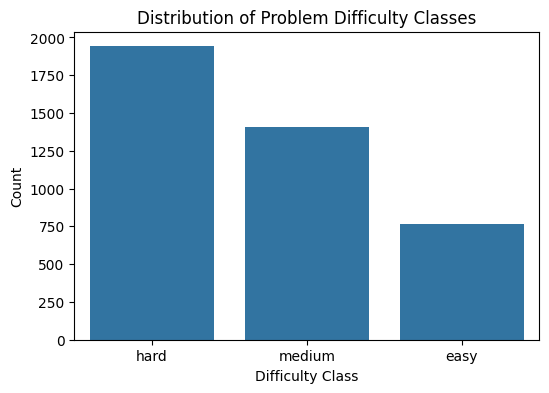

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='problem_class', data=df)
plt.title("Distribution of Problem Difficulty Classes")
plt.xlabel("Difficulty Class")
plt.ylabel("Count")
plt.show()


# Text Preparation

In [9]:
df['full_text'] = (
    df['title'] + " " +
    df['description'] + " " +
    df['input_description'] + " " +
    df['output_description']
)


In [10]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['full_text'] = df['full_text'].apply(clean_text)


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['problem_class'] = le.fit_transform(df['problem_class'])


In [12]:
df.drop(columns=['title','description','input_description','output_description'],inplace=True)
df.head()

,problem_class,problem_score,full_text
0,1,9.7,uuu unununium (uuu) was the name of the chemic...
1,1,9.7,house building a number of eccentrics from cen...
2,1,9.6,mario or luigi mario and luigi are playing a g...
3,1,9.6,the wire ghost žofka is bending a copper wire....
4,1,9.6,barking up the wrong tree your dog spot is let...


Remove Stopwords

In [13]:
from nltk.corpus import stopwords
stopword_set = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stopword_set])

df['full_text'] = df['full_text'].apply(remove_stopwords)

Tokenization

In [14]:
def tokenize(text):
  t_text= word_tokenize(text)
  return t_text

df['full_text']= df['full_text'].apply(tokenize)

Lemnatization


In [15]:
ps =PorterStemmer()
def stem_words(text):
  return " ".join ([ps.stem(word) for word in text])

df['full_text']= df['full_text'].apply(stem_words)

In [16]:
df['text_length'] = df['full_text'].apply(len)

In [17]:
df.head()

,problem_class,problem_score,full_text,text_length
0,1,9.7,uuu unununium ( uuu ) name chemic element atom...,992
1,1,9.7,hous build number eccentr central new york dec...,900
2,1,9.6,mario luigi mario luigi play game pick distinc...,908
3,1,9.6,wire ghost žofka bend copper wire . start stra...,860
4,1,9.6,bark wrong tree dog spot let loos park . well ...,1293


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_text = tfidf.fit_transform(df['full_text'])


In [19]:
X_num = df[['text_length']].values

In [20]:
X_text_train, X_text_test, X_num_train, X_num_test, \
y_class_train, y_class_test = train_test_split(X_text, X_num, df['problem_class'],test_size=0.2, random_state=42)


In [21]:
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)


In [22]:
X_train = hstack([X_text_train, X_num_train_scaled])
X_test  = hstack([X_text_test,  X_num_test_scaled])

# Classification model

Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_class_train)


LogisticRegression(max_iter=1000)

In [24]:
y_class_pred = clf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_class_test, y_class_pred))
print(classification_report(y_class_test, y_class_pred))

Accuracy: 0.5382746051032807
              precision    recall  f1-score   support

           0       0.57      0.32      0.41       136
           1       0.60      0.73      0.66       425
           2       0.39      0.34      0.36       262

    accuracy                           0.54       823
   macro avg       0.52      0.46      0.48       823
weighted avg       0.53      0.54      0.52       823



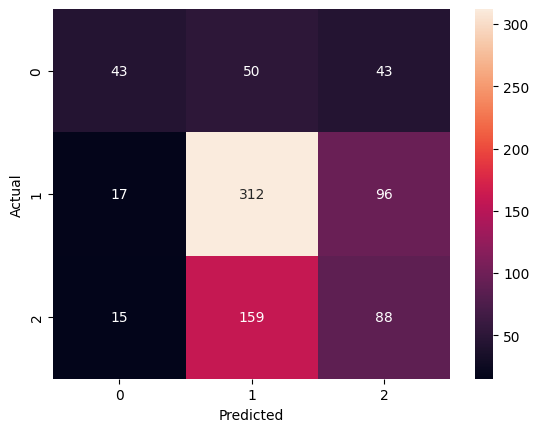

In [25]:
sns.heatmap(confusion_matrix(y_class_test, y_class_pred),
            annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

XGB

In [26]:
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_class_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=3, ...)

In [27]:
y_class_pred = xgb_clf.predict(X_test)
y_class_proba = xgb_clf.predict_proba(X_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_class_test, y_class_pred))
print(classification_report(y_class_test, y_class_pred))

Accuracy: 0.5394896719319563
              precision    recall  f1-score   support

           0       0.51      0.32      0.39       136
           1       0.61      0.74      0.67       425
           2       0.38      0.34      0.36       262

    accuracy                           0.54       823
   macro avg       0.50      0.46      0.47       823
weighted avg       0.52      0.54      0.52       823



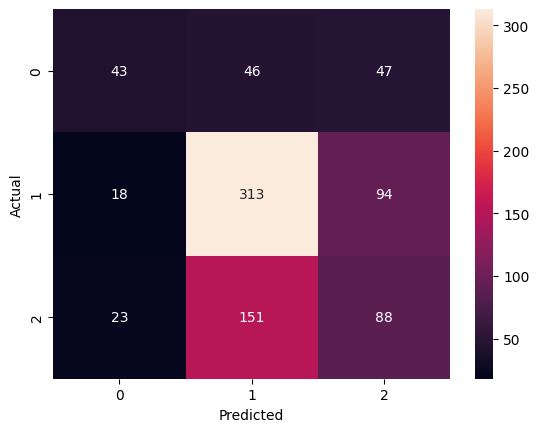

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_class_test, y_class_pred),
            annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_class_train)
y_rf_pred = rf_clf.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Random Forest Accuracy:", accuracy_score(y_class_test, y_rf_pred))
print(classification_report(y_class_test, y_rf_pred))

Random Forest Accuracy: 0.5492102065613609
              precision    recall  f1-score   support

           0       0.59      0.18      0.27       136
           1       0.57      0.91      0.70       425
           2       0.40      0.16      0.23       262

    accuracy                           0.55       823
   macro avg       0.52      0.42      0.40       823
weighted avg       0.52      0.55      0.48       823



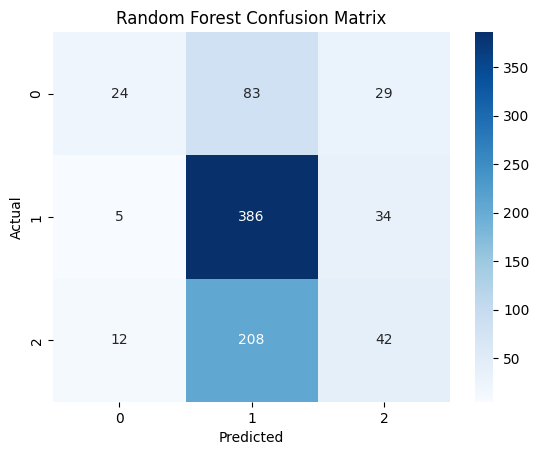

In [32]:
sns.heatmap(confusion_matrix(y_class_test, y_rf_pred),
            annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


# regression model

In [34]:
y_score = df['problem_score']
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, X_num_train, X_num_test, \
y_score_train, y_score_test = train_test_split(
    X_text,
    X_num,
    y_score,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled  = scaler.transform(X_num_test)

In [36]:
from scipy.sparse import hstack

X_train = hstack([X_text_train, X_num_train_scaled])
X_test  = hstack([X_text_test,  X_num_test_scaled])

Linear Regression

In [37]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_score_train)

y_lin_pred = lin_reg.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression R² Score:", r2_score(y_score_test, y_lin_pred))
print("Linear Regression MAE:", mean_absolute_error(y_score_test, y_lin_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_score_test, y_lin_pred)))

Linear Regression R² Score: -2.3559934867672028
Linear Regression MAE: 3.2134189484345876
Linear Regression RMSE: 4.013675352724888


Random Forest

In [39]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train, y_score_train)
y_rf_pred = rf_reg.predict(X_test)

In [40]:
# Evaluation
print("Random Forest R² Score:", r2_score(y_score_test, y_rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_score_test, y_rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_score_test, y_rf_pred)))

Random Forest R² Score: 0.13595225958920354
Random Forest MAE: 1.6932161822363567
Random Forest RMSE: 2.0365756941176714


Gradient Boost

In [41]:
from sklearn.ensemble import GradientBoostingRegressor

reg = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

reg.fit(X_train, y_score_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [42]:
y_score_pred = reg.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("R² Score:", r2_score(y_score_test, y_score_pred))
print("MAE:", mean_absolute_error(y_score_test, y_score_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_score_test, y_score_pred)))

R² Score: 0.15354335412811537
MAE: 1.6759275548072607
RMSE: 2.015737830206395


# Classification Pipepline

In [44]:
import pandas as pd
df = pd.read_json("problems_data.jsonl", lines=True)

In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['problem_class_encoded'] = le.fit_transform(df['problem_class'])

In [46]:
import joblib
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [47]:
def combine_text(X):
    return (
        X['description'].fillna('') + " " +
        X['input_description'].fillna('') + " " +
        X['output_description'].fillna('')
    )


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier, XGBRegressor


In [51]:
classification_pipeline = Pipeline([
    ('combine', FunctionTransformer(combine_text, validate=False)),
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words='english'
    )),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])


In [52]:
X = df[['description', 'input_description', 'output_description']]
y_class = df['problem_class_encoded']

classification_pipeline.fit(X, y_class)


Pipeline(steps=[('combine',
                 FunctionTransformer(func=<function combine_text at 0x7b4a201ae700>)),
                ('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [53]:
joblib.dump(classification_pipeline, "difficulty_classifier.pkl")


['difficulty_classifier.pkl']

# Regression Pipeline

In [ ]:
regression_pipeline = Pipeline([
    ('combine', FunctionTransformer(combine_text, validate=False)),
    ('tfidf', TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words='english'
    )),
    ('model', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ))
])


In [ ]:
y_score = df['problem_score']

regression_pipeline.fit(X, y_score)


Pipeline(steps=[('combine',
                 FunctionTransformer(func=<function combine_text at 0x7b44cf3c39c0>)),
                ('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              e...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
joblib.dump(regression_pipeline, "difficulty_regressor.pkl")


['difficulty_regressor.pkl']

In [ ]:
sample = pd.DataFrame({
    'description': ["Given an array, find the maximum sum subarray"],
    'input_description': ["First line contains n"],
    'output_description': ["Print maximum sum"]
})

cls_pred = classification_pipeline.predict(sample)
score_pred = regression_pipeline.predict(sample)

print("Class:", le.inverse_transform(cls_pred))
print("Score:", score_pred)


Class: ['easy']
Score: [4.0582023]
